In [1]:
import numpy as np
import pandas as pd
import glob, os, sys, vcf, pickle, yaml, itertools, sparse
import warnings
warnings.filterwarnings("ignore")

import Bio
import Bio.SeqUtils
from Bio import Seq, SeqIO

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

print(df_rif.shape, df_rif_val.shape)
#rpoBC_seqdf = pd.read_csv("Rifampicin/rpoBC_seqdf.csv", index_col=[0])

df_cryptic = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/cryptic_data_curated_filtered.csv")
df_rollingDB = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_combined_data.csv")

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from inSilicoMut_utils import *

# MIC_model_analysis = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/MIC/tiers=1+2/dropAF_noSyn_unpooled/model_analysis.csv")
# model_analysis = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=ALL/dropAF_noSyn_unpooled/model_analysis.csv")
# LRT_results = pd.read_csv('/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=ALL/dropAF_noSyn_unpooled/LRT_results.csv')

# model_matrix = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=ALL/dropAF_noSyn_unpooled/model_matrix.pkl")
# # model_analysis_withSyn = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=ALL/dropAF_withSyn_unpooled/model_analysis.csv")

#RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates_fixed_annot.csv")
train_test_df = RIF_isolate_variants.query("category in ['train', 'test']")[~pd.isnull(RIF_isolate_variants["mutation"])]
# RIF_isolate_variants["new_variant"] = ["_".join(val.split("_")[1:]) if type(val) == str else val for val in RIF_isolate_variants.mutation.values]

# for i, row in RIF_isolate_variants.iterrows():
    
#     if row["AF"] == ".":
#         RIF_isolate_variants.loc[i, "AF"] = 0.76
#     elif ~pd.isnull(row["AF"]):
#         RIF_isolate_variants.loc[i, "AF"] = float(row["AF"])

(9137, 19) (1406, 17)


In [2]:
###### IMPORT MANY ADDITIONAL FILES FOR THE ANALYSIS ######

#df_insilico_pred = pd.read_csv("Rifampicin/insilico_mutagenesis/rpoB_WHO_predictions_scores.csv")
df_insilico_pred = pd.read_csv("/home/sak0914/RIF_insilico_predictions.csv")
df_insilico_pred["MIC"] = np.exp2(df_insilico_pred["log_MIC"])

# RIF_rpoBC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
# BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
h37Rv_seq = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

# RIF_rpoBC_saliency_df = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")
# RIF_rpoBC_saliency_df["Pos"] = [int(float(val)) if val.replace('.', '').isnumeric() else val for val in RIF_rpoBC_saliency_df["Pos"].values]

In [70]:
# # get all mutations that need to be updated
# fix_mut = RIF_isolate_variants.loc[~pd.isnull(RIF_isolate_variants["PROT"])].sort_values(["Isolate", "new_variant"]).query("PROT != new_variant & NUC != new_variant").drop_duplicates("PROT", keep="first")["PROT"].values
# print(len(fix_mut))

# for i, mut in enumerate(fix_mut):
        
#     gene = RIF_isolate_variants.query("PROT==@mut")["GENE"].values[0]
    
#     if gene == "rpoB":
#         start = 759807
#         end = 763325
#     elif gene == "rpoC":
#         start = 763370
#         end = 767320 
#         print("rpoC")
#     else:
#         raise ValueError(gene)
    
#     num = []

#     for char in mut:
#         if char.isnumeric():
#             num.append(char)
    
#     codon_num = int("".join(num)) 
#     _, codon_coords = get_codon_from_seq(h37Rv_seq, codon_num, start, end)

#     for isolate in RIF_isolate_variants.query("PROT==@mut").Isolate.unique():

#         if len(RIF_isolate_variants.query("Isolate == @isolate & POS in @codon_coords")) == 1:
#             RIF_isolate_variants.loc[(RIF_isolate_variants["Isolate"]==isolate) & (RIF_isolate_variants["PROT"]==mut), ["mutation", "new_variant"]] = [f'rpoB_{mut}', mut]
            
#     if i % 10 == 0:
#         print(i, mut)

In [13]:
MXF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates.csv")
MXF_isolate_variants_fixed = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates_fixed_annot.csv")
MXF_isolate_variants_fixed["new_variant"] = ["_".join(val.split("_")[1:]) if type(val) == str else val for val in MXF_isolate_variants_fixed.mutation.values]
len(MXF_isolate_variants.Isolate.unique()), len(MXF_isolate_variants_fixed.Isolate.unique())

(8569, 8562)

In [29]:
# MXF_isolate_variants_fixed.query("new_variant != PROT & new_variant != NUC")

# Mutations in RIF-R Isolates that don't have Category 1 Mutations

In [2]:
Cat1_mutations = who_variants.query("drug=='RIF' & confidence.str.contains('1')")["mutation"].values

# include across all AFs here. If the mutation is present, regardless of AF or filters, exclude that mutation
# only consider train and test dataset
Cat1_isolates = RIF_isolate_variants.query("category in ['train', 'test'] & mutation in @Cat1_mutations")["Isolate"].values

print(f"{len(Cat1_isolates)} isolates have Category 1 RIF-R-associated mutations")

R_isolates_noCat1 = RIF_isolate_variants.query("category in ['train', 'test'] & RIF_midpoint > 0.5 & Isolate not in @Cat1_isolates")

ref_isolates = R_isolates_noCat1.loc[pd.isnull(R_isolates_noCat1["mutation"])]["Isolate"].values
print(f"{len(ref_isolates)} resistant isolates have reference H37Rv sequence")

R_isolates_noCat1 = R_isolates_noCat1.loc[~pd.isnull(R_isolates_noCat1["mutation"])].reset_index(drop=True)
print(f"{len(R_isolates_noCat1.Isolate.unique())} RIF-R isolates that have other mutations")

4374 isolates have Category 1 RIF-R-associated mutations
20 resistant isolates have reference H37Rv sequence
226 RIF-R isolates that have other mutations


In [3]:
len(Cat1_mutations)

24

# Nonsynonymous mutations first

In [30]:
# drop duplicates because if multiple SNPs occur in the same codon, they are assigned the same value in the mutation column, and the mutaiton will get double counted
# then groupby mutation and keep only those that occur in at least N isolates
N_thresh = 5
syn_categories = ['synonymous_variant', 'upstream_gene_variant', 'intergenic_region']

most_frequent_nonsyn = R_isolates_noCat1.query("EFFECT not in @syn_categories").drop_duplicates(["mutation", "Isolate"], keep="first").groupby("mutation").filter(lambda x: len(x) >= N_thresh)["mutation"].unique()
most_frequent_syn = R_isolates_noCat1.query("EFFECT in @syn_categories").drop_duplicates(["mutation", "Isolate"], keep="first").groupby("mutation").filter(lambda x: len(x) >= N_thresh)["mutation"].unique()

len(most_frequent_nonsyn), len(most_frequent_syn)

(12, 6)

In [51]:
train_test_isolates = RIF_isolate_variants.query("category in ['train', 'test']")["Isolate"].unique()
print(len(train_test_isolates))

def chi_squared_test_comutation(mut1, mut2, all_isolates=RIF_isolate_variants.Isolate.unique()):
    
    isolates_mut1 = set(train_test_df.query("mutation==@mut1 & FILTER=='PASS' & AF > 0.75")["Isolate"])
    isolates_mut2 = set(train_test_df.query("mutation==@mut2 & FILTER=='PASS' & AF > 0.75")["Isolate"])
    
    if len(isolates_mut1.intersection(isolates_mut2)) == 0:
        return np.nan
    
    # Create a contingency table (as a NumPy array) with observed counts
    contingency_table = np.array([[len(isolates_mut1.intersection(isolates_mut2)), len(isolates_mut1 - isolates_mut2)],
                                  [len(isolates_mut2 - isolates_mut1), len(set(all_isolates) - isolates_mut1 - isolates_mut2)]])

    # print(contingency_table)
    # Perform the chi-square test for independence
    chi2, pval, dof, expected_freq = st.chi2_contingency(contingency_table)
    # print(expected_freq.astype(int))
    return pval

9137


In [46]:
N_thresh = 5
freq_mutations = RIF_isolate_variants.loc[~pd.isnull(RIF_isolate_variants["mutation"])].query("RIF_midpoint > 0.5").drop_duplicates(["mutation", "Isolate"], keep="first").groupby("mutation").filter(lambda x: len(x) >= N_thresh)["mutation"].unique()
len(freq_mutations)

192

In [47]:
all_mutation_pairs = list(itertools.combinations(freq_mutations, 2))
len(all_mutation_pairs)

18336

In [49]:
len(RIF_isolate_variants.query("RIF_midpoint > 0.5").Isolate.unique())

5373

In [52]:
results_df = pd.DataFrame(columns = ["Mut1", "Mut2", "chi2_pval"])

for i, (mut1, mut2) in enumerate(all_mutation_pairs):
    
    results_df.loc[i, :] = [mut1, mut2, chi_squared_test_comutation(mut1, mut2, RIF_isolate_variants.query("RIF_midpoint > 0.5").Isolate.unique())]
    
    if i % 1000 == 0:
        print(i)

results_df.to_csv("Rifampicin/comutation_chisquared_results.csv", index=False)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000


In [53]:
results_df = pd.read_csv("Rifampicin/comutation_chisquared_results.csv")

In [54]:
results_df["Bonferroni_chi2_pval"] = results_df["chi2_pval"] * len(results_df.loc[~pd.isnull(results_df["chi2_pval"])])
print(len(results_df.loc[~pd.isnull(results_df["chi2_pval"])]))

significant_comut_df = results_df.query("Bonferroni_chi2_pval < 0.05").sort_values("Bonferroni_chi2_pval")
print(len(significant_comut_df))

1120
238


In [57]:
mut = most_frequent_nonsyn[1]
significant_comut_df.query("Mut1 == @mut | Mut2 == @mut")

,Mut1,Mut2,chi2_pval,Bonferroni_chi2_pval
1413,rpoB_p.Asp435Tyr,rpoB_p.Met434Ile,5.203698e-63,5.828142e-60
12684,rpoB_p.Asp435Gly,rpoB_p.Met434Ile,1.495548e-24,1.675013e-21
6924,rpoB_c.2628T>G,rpoB_p.Met434Ile,2.381469e-09,2.667245e-06
7664,mazF2_c.-4753G>A,rpoB_p.Met434Ile,4.854591e-08,5.437142e-05


In [43]:
chi_squared_test_comutation(mut, "rpoB_p.Pro454Leu")

[[    3    15]
 [    3 10522]]
[[    0    17]
 [    5 10519]]


6.399895229275226e-134

In [33]:
df_insilico_pred.query("mutation==@mut")

,log_MIC,mutation,confidence,genome_index,MIC
106,4.022343,rpoB_p.Ser450Gln,2) Assoc w R - Interim,"761154,761155",16.249721


In [34]:
df_insilico_pred.query("mutation=='rpoC_p.Gly332Ser'")

,log_MIC,mutation,confidence,genome_index,MIC


In [149]:
len(train_test_df["mutation"].unique())

952

In [134]:
all_mutation_pairs

NameError: name 'all_mutation_pairs' is not defined

In [78]:
df_insilico_pred.query("mutation in @most_frequent_nonsyn")

,log_MIC,mutation,confidence,genome_index,MIC,codon_num
32,1.754466,rpoB_p.Arg448Gln,2) Assoc w R - Interim,761149,3.374015,448
37,2.939822,rpoB_p.His445Pro,2) Assoc w R - Interim,761140,7.673168,445
57,0.253896,rpoB_p.Asp435Gly,2) Assoc w R - Interim,761110,1.192423,435
60,-2.621839,rpoB_p.Met434Ile,2) Assoc w R - Interim,761108,0.162460,434
103,4.686055,rpoB_p.Ser450Met,2) Assoc w R - Interim,"761154,761155",25.742049,450
106,4.022343,rpoB_p.Ser450Gln,2) Assoc w R - Interim,"761154,761155",16.249721,450
330,-2.975815,rpoB_p.Ile491Leu,3) Uncertain significance,761277,0.127113,491
705,-4.092366,rpoB_p.Glu250Gly,5) Not assoc w R,760555,0.058624,250
706,-3.969505,rpoB_p.Val695Leu,5) Not assoc w R,761889,0.063835,695


In [28]:
train_test_isolates = RIF_isolate_variants.query("category in ['train', 'test']")["Isolate"].unique()

#for mut in ["rpoB_p.Ser450Met"]:
for mut in most_frequent_nonsyn:
    
    isolates_with_mut = RIF_isolate_variants.loc[~pd.isnull(RIF_isolate_variants["mutation"])].query("Isolate in @train_test_isolates & mutation == @mut & AF >= 0.75 & FILTER == 'PASS'")["Isolate"].unique()
    isolates_without_mut = list(set(train_test_isolates) - set(isolates_with_mut))
    
    plot_df = df_rif[["ROLLINGDB_ID", "RIF_midpoint", "category"]]
    plot_df.loc[plot_df["ROLLINGDB_ID"].isin(isolates_with_mut), mut] = 1
    plot_df.loc[plot_df["ROLLINGDB_ID"].isin(isolates_without_mut), mut] = 0
    
    assert len(plot_df.loc[pd.isnull(plot_df[mut])]) == 0
    plot_df[mut] = plot_df[mut].astype(int)
    plot_df["log2_MIC"] = np.log2(plot_df["RIF_midpoint"])
    
    MIC_with_mut = plot_df.loc[plot_df[mut]==1]["log2_MIC"].values
    MIC_without_mut = plot_df.loc[plot_df[mut]==0]["log2_MIC"].values
    
    if np.mean(MIC_with_mut) > np.mean(MIC_without_mut):
        alt = "greater"
        title_prefix = "MIC Increase"
    # else:
    #     alt = "less"
    #     title_prefix = "MIC Decrease"
        
        sns.histplot(data=plot_df,
             x="log2_MIC",
             hue=mut,
             common_norm=False,
             stat="probability",
             multiple="dodge"
            )
    
        enrich_pval = st.mannwhitneyu(MIC_with_mut,
                                      MIC_without_mut,
                                      alternative=alt
                                     )[1]

        plt.title(f"{title_prefix}, pval = {enrich_pval}")
        sns.despine()
        plt.show()
        
    else:
        print(f"{mut} does not increase MIC")

In [86]:
plot_df

,ROLLINGDB_ID,RIF_midpoint,category,rpoB_p.Ser450Gln
0,ERR4810491,0.03,original_train_set,0
1,ERR4810493,0.09,original_train_set,0
2,ERR4810494,0.09,original_train_set,0
3,ERR4810495,0.09,original_test_set,0
4,ERR4810497,0.03,original_train_set,0
...,...,...,...,...
9132,SAMEA3558149,15.00,original_train_set,0
9133,SAMEA3558181,60.00,original_train_set,0
9134,SAMEA3558209,120.00,original_test_set,0
9135,SAMEA3558222,15.00,original_test_set,0


In [75]:
df_rif.query("ROLLINGDB_ID in @isolates_without_mut")[["ROLLINGDB_ID", "RIF_midpoint"]]

,ROLLINGDB_ID,RIF_midpoint
0,ERR4810491,0.03
1,ERR4810493,0.09
2,ERR4810494,0.09
3,ERR4810495,0.09
4,ERR4810497,0.03
...,...,...
9132,SAMEA3558149,15.00
9133,SAMEA3558181,60.00
9134,SAMEA3558209,120.00
9135,SAMEA3558222,15.00


In [76]:
df_rif.query("ROLLINGDB_ID in @isolates_with_mut")[["ROLLINGDB_ID", "RIF_midpoint"]]

,ROLLINGDB_ID,RIF_midpoint
7739,03R0070,1.0
8501,Peru4612,50.0
8614,Peru4899,50.0
8622,Peru4907,50.0
8792,Peru5130,50.0
8833,Peru5433,50.0
9021,SAMN02360596,16.0
9083,SAMN02360610,16.0


In [32]:
RIF_isolate_variants

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
0,761110.0,A,T,PASS,1.0,rpoB,missense_variant,c.1304A>T,p.Asp435Val,00R0312,rpoB_p.Asp435Val,1.0000,train,p.Asp435Val
1,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,00R0312,rpoC_c.1626C>G,1.0000,train,c.1626C>G
2,761155.0,C,G,PASS,1.0,rpoB,missense_variant,c.1349C>G,p.Ser450Trp,00R0435,rpoB_p.Ser450Trp,1.0000,train,p.Ser450Trp
3,761110.0,A,T,PASS,1.0,rpoB,missense_variant,c.1304A>T,p.Asp435Val,00R0453,rpoB_p.Asp435Val,1.0000,train,p.Asp435Val
4,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,00R0453,rpoC_c.1626C>G,1.0000,train,c.1626C>G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C292,NaN,0.0450,validation,NaN
25236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C314,NaN,0.7500,validation,NaN
25237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C429,NaN,0.0450,validation,NaN
25238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C434,NaN,0.1875,validation,NaN


In [24]:
RIF_isolate_variants.query("mutation=='mazF2_c.-4753G>A'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
260,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,1762,mazF2_c.-4753G>A,5.000,test,c.-4753G>A
269,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,1766,mazF2_c.-4753G>A,5.000,test,c.-4753G>A
276,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,1768,mazF2_c.-4753G>A,5.000,train,c.-4753G>A
281,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,1770,mazF2_c.-4753G>A,5.000,train,c.-4753G>A
295,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,1780,mazF2_c.-4753G>A,5.000,train,c.-4753G>A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23338,759746.0,C,T,PASS,0.99,mazF2,upstream_gene_variant,c.-4753G>A,.,SAMN02381034,mazF2_c.-4753G>A,0.060,train,c.-4753G>A
23542,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,TDR188S166L002,mazF2_c.-4753G>A,0.125,test,c.-4753G>A
23614,759746.0,C,T,PASS,0.99,mazF2,upstream_gene_variant,c.-4753G>A,.,TDR34S89L002,mazF2_c.-4753G>A,3.000,train,c.-4753G>A
23645,759746.0,C,T,PASS,1.0,mazF2,upstream_gene_variant,c.-4753G>A,.,TDR54S149L002,mazF2_c.-4753G>A,0.125,train,c.-4753G>A


In [28]:
insilico_mut = set(df_insilico_pred["mutation"])
dataset_mut = set(RIF_isolate_variants.query("category in ['train', 'test']")["mutation"])

len(insilico_mut - dataset_mut)

384

In [29]:
len(insilico_mut)

711

In [19]:
len(solo_results.query("drug=='Levofloxacin' & Initial_Confidence_Grading == '1) Assoc w R'"))

13

In [20]:
len(solo_results.query("drug=='Moxifloxacin' & Initial_Confidence_Grading == '1) Assoc w R'"))

11

In [21]:
len(solo_results.query("drug=='Bedaquiline' & Initial_Confidence_Grading == '1) Assoc w R'"))

27

In [23]:
len(solo_results.query("drug=='Linezolid' & Initial_Confidence_Grading == '1) Assoc w R'"))

2

In [17]:
solo_results.query("variant in @most_frequent_nonsyn")

,drug,variant,Initial_Confidence_Grading
43222,Rifampicin,rpoB_p.Arg448Gln,3) Uncertain significance
43315,Rifampicin,rpoB_p.Asp435Gly,3) Uncertain significance
43420,Rifampicin,rpoB_p.Glu250Gly,4) Not assoc w R - interim
43549,Rifampicin,rpoB_p.His445Pro,3) Uncertain significance
43583,Rifampicin,rpoB_p.Ile491Leu,3) Uncertain significance
43689,Rifampicin,rpoB_p.Met434Ile,3) Uncertain significance
43814,Rifampicin,rpoB_p.Ser450Gln,1) Assoc w R
43817,Rifampicin,rpoB_p.Ser450Met,3) Uncertain significance
43968,Rifampicin,rpoB_p.Val695Leu,3) Uncertain significance
44643,Rifampicin,rpoC_p.Ala172Val,5) Not assoc w R


In [16]:
solo_results.query("variant in @most_frequent_syn")

,drug,variant,Initial_Confidence_Grading
42886,Rifampicin,rpoB_c.2628T>G,5) Not assoc w R
42956,Rifampicin,rpoB_c.309C>T,5) Not assoc w R
42986,Rifampicin,rpoB_c.3225T>C,5) Not assoc w R
44120,Rifampicin,rpoC_c.1626C>G,5) Not assoc w R


In [173]:
most_frequent_nonsyn_df = RIF_isolate_variants.query("category in ['train', 'test'] & mutation in @most_frequent_nonsyn")
most_frequent_nonsyn_df["Binary"] = (most_frequent_nonsyn_df["RIF_midpoint"] > 0.5).astype(int)



In [174]:
for mut in most_frequent_nonsyn:
    
    print(mut, most_frequent_nonsyn_df.query("mutation==@mut")["Binary"].mean())

rpoB_p.Ser450Gln 1.0
rpoB_p.Met434Ile 1.0
rpoB_p.Asp435Gly 0.9272727272727272
rpoB_p.His445Pro 1.0
rpoB_p.Arg448Gln 1.0
rpoB_p.Ser450Met 0.875
rpoC_p.Gly594Glu 0.37302133516861663
rpoB_p.Val695Leu 0.6481481481481481
rpoC_p.Ala172Val 0.21072088724584104
rpoC_p.Arg173Arg 0.20925925925925926
rpoC_p.Pro601Leu 0.13672922252010725
rpoB_p.Ile491Leu 1.0
rpoB_p.Glu250Gly 0.18681318681318682


In [177]:
who_variants.query("mutation.str.contains('rpoC') & mutation in @most_frequent_nonsyn")

,drug,genome_index,confidence,mutation
15544,RIF,765171,5) Not assoc w R,rpoC_p.Pro601Leu
15547,RIF,"763884,763885",5) Not assoc w R,rpoC_p.Ala172Val
15548,RIF,765150,5) Not assoc w R,rpoC_p.Gly594Glu


In [182]:
df_insilico_pred.query("confidence != '1) Assoc w R' & MIC <= 0.5 & MIC >= 0.25")[["mutation", "confidence", "MIC"]].sort_values("MIC", ascending=False)


,mutation,confidence,MIC
81,rpoB_p.Asp435del,2) Assoc w R - Interim,0.444933
59,rpoB_p.His445Gln,2) Assoc w R - Interim,0.351977
58,rpoB_p.Leu430Arg,2) Assoc w R - Interim,0.325761
26,rpoB_p.Asn437Tyr,2) Assoc w R - Interim,0.314951


In [186]:
df_insilico_pred.query("confidence == '3) Uncertain significance'").MIC.max()

1.0277802233212827

In [188]:
np.unique(df_insilico_pred.query("confidence == '3) Uncertain significance'").MIC)[-10:]

array([0.07773386, 0.07850019, 0.08088064, 0.08272456, 0.08599572,
       0.08815919, 0.08961475, 0.09427059, 0.12711309, 1.02778022])

In [192]:
np.min(np.unique(df_insilico_pred.query("confidence == '3) Uncertain significance'").MIC))

0.05349869832491216

In [200]:
df_insilico_pred.query("MIC < @h37Rv_MIC").confidence.value_counts()

3) Uncertain significance    352
5) Not assoc w R               4
2) Assoc w R - Interim         2
Name: confidence, dtype: int64

In [198]:
df_insilico_pred.query("MIC < @h37Rv_MIC & confidence=='2) Assoc w R - Interim'")

,log_MIC,mutation,confidence,genome_index,MIC,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
91,-4.179714,rpoB_p.Thr427Ala,2) Assoc w R - Interim,761085,0.055180,rpoB,761085,A,G,rpoBC,761085.0,0.017243,-0.012928,1.0,1.0,0,0,0,0.002157
100,-4.136628,rpoB_p.Thr427Gly,2) Assoc w R - Interim,"761085,761086",0.056853,rpoB,761085,A,G,rpoBC,761085.0,0.017243,-0.012928,1.0,1.0,0,0,0,-0.001869


In [194]:
# H37Rv prediction
h37Rv_MIC = np.exp2(-4.0937176)
h37Rv_MIC

0.05856905389315324

In [181]:
df_insilico_pred.query("confidence != '1) Assoc w R' & MIC > 0.5")[["mutation", "confidence", "MIC"]].sort_values("MIC", ascending=False)


,mutation,confidence,MIC
113,rpoB_p.Ser450Val,2) Assoc w R - Interim,25.954927
103,rpoB_p.Ser450Met,2) Assoc w R - Interim,25.742049
98,rpoB_p.Gln432_Met434del,2) Assoc w R - Interim,21.163950
71,rpoB_p.Gln432_Phe433del,2) Assoc w R - Interim,20.421170
102,rpoB_p.His445Gly,2) Assoc w R - Interim,18.549530
115,rpoB_p.Ser450Cys,2) Assoc w R - Interim,18.095306
109,rpoB_p.Asp435Leu,2) Assoc w R - Interim,18.030650
72,rpoB_p.Asp435_Pro439del,2) Assoc w R - Interim,17.704899
74,rpoB_p.His445_Lys446del,2) Assoc w R - Interim,17.208894
108,rpoB_p.His445Phe,2) Assoc w R - Interim,17.156829


In [149]:
df_insilico_pred.query("mutation in @most_frequent_nonsyn").sort_values("MIC", ascending=False)

,log_MIC,mutation,confidence,genome_index,MIC
103,4.686055,rpoB_p.Ser450Met,2) Assoc w R - Interim,"761154,761155",25.742049
106,4.022343,rpoB_p.Ser450Gln,2) Assoc w R - Interim,"761154,761155",16.249721
37,2.939822,rpoB_p.His445Pro,2) Assoc w R - Interim,761140,7.673168
32,1.754466,rpoB_p.Arg448Gln,2) Assoc w R - Interim,761149,3.374015
57,0.253896,rpoB_p.Asp435Gly,2) Assoc w R - Interim,761110,1.192423
60,-2.621839,rpoB_p.Met434Ile,2) Assoc w R - Interim,761108,0.162460
330,-2.975815,rpoB_p.Ile491Leu,3) Uncertain significance,761277,0.127113
706,-3.969505,rpoB_p.Val695Leu,5) Not assoc w R,761889,0.063835
705,-4.092366,rpoB_p.Glu250Gly,5) Not assoc w R,760555,0.058624


In [141]:
df_insilico_pred.query("mutation.str.contains('delins')")

,log_MIC,mutation,confidence,genome_index,MIC
43,4.194042,rpoB_p.Gln432_Asp435delinsHis,2) Assoc w R - Interim,761100,18.303428
73,4.063415,rpoB_p.Met434_Asn437delinsIle,2) Assoc w R - Interim,761106,16.718981
83,-3.631738,rpoB_p.Thr427_Gln429delinsLys,2) Assoc w R - Interim,761085,0.080675
95,-1.324229,rpoB_p.Asp435_Gln436delinsGlu,2) Assoc w R - Interim,761109,0.399363


In [8]:
df_insilico_pred.query("confidence=='3) Uncertain significance' & MIC > ")

,log_MIC,mutation,confidence,genome_index,MIC
116,-4.096849,rpoB_p.Glu825Gly,3) Uncertain significance,762280,0.058442
117,-4.100134,rpoB_p.Phe1005Val,3) Uncertain significance,762819,0.058309
118,-4.108270,rpoB_p.Phe548Leu,3) Uncertain significance,761448,0.057981
119,-4.090483,rpoB_p.Phe669Leu,3) Uncertain significance,761813,0.058701
120,-4.091029,rpoB_c.-117G>A,3) Uncertain significance,759690,0.058678
...,...,...,...,...,...
698,-4.114056,rpoB_p.Asp103Glu,3) Uncertain significance,760115,0.057749
699,0.039532,rpoB_p.Ile491Tyr,3) Uncertain significance,"761277,761278",1.027780
700,-4.095988,rpoB_p.Ile542Lys,3) Uncertain significance,"761431,761432",0.058477
701,-4.090366,rpoB_p.Val549Gly,3) Uncertain significance,"761452,761453",0.058705


In [136]:
pos = 761154
ref = h37Rv_seq.seq[pos-1]
idx = RIF_rpoBC_saliency_df.loc[RIF_rpoBC_saliency_df["Pos"]==pos].index.values[0]
print(f"Ref: {ref}")
dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)))

Ref: T


{'A': 0.0, 'C': 0.51478213, 'T': 0.0, 'G': 0.7186825, '-': 0.0}

In [128]:
pos = 761155
ref = h37Rv_seq.seq[pos-1]
idx = RIF_rpoBC_saliency_df.loc[RIF_rpoBC_saliency_df["Pos"]==pos].index.values[0]
print(f"Ref: {ref}")
dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)))

Ref: C


{'A': 0.029062241, 'C': 0.0, 'T': 3.2442644, 'G': 1.334161, '-': 0.0}

In [135]:
R_isolates_noCat1.query("FILTER == 'PASS' & mutation == 'rpoB_p.Ser450Met'")#.drop_duplicates(["mutation", "POS"]).sort_values("POS")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
83,761154.0,T,A,PASS,1.0,rpoB,missense_variant,c.1348T>A,p.Ser450Thr,ERR3287636,rpoB_p.Ser450Met,4.0,test,p.Ser450Met
84,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR3287636,rpoB_p.Ser450Met,4.0,test,p.Ser450Met
247,761154.0,T,A,PASS,1.0,rpoB,missense_variant,c.1348T>A,p.Ser450Thr,ERR4813066,rpoB_p.Ser450Met,8.0,train,p.Ser450Met
248,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4813066,rpoB_p.Ser450Met,8.0,train,p.Ser450Met
251,761154.0,T,A,PASS,1.0,rpoB,missense_variant,c.1348T>A,p.Ser450Thr,ERR4813088,rpoB_p.Ser450Met,8.0,test,p.Ser450Met
252,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4813088,rpoB_p.Ser450Met,8.0,test,p.Ser450Met
255,761154.0,T,A,PASS,1.0,rpoB,missense_variant,c.1348T>A,p.Ser450Thr,ERR4813089,rpoB_p.Ser450Met,8.0,test,p.Ser450Met
256,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,ERR4813089,rpoB_p.Ser450Met,8.0,test,p.Ser450Met
487,761154.0,T,A,PASS,1.0,rpoB,missense_variant,c.1348T>A,p.Ser450Thr,Peru4032,rpoB_p.Ser450Met,50.0,test,p.Ser450Met
488,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,Peru4032,rpoB_p.Ser450Met,50.0,test,p.Ser450Met


In [139]:
df_insilico_pred.query("mutation in @most_frequent_nonsyn")[["mutation", "genome_index", "confidence", "saliency_score", "MIC"]]

,mutation,genome_index,confidence,saliency_score,MIC
32,rpoB_p.Arg448Gln,761149,2) Assoc w R - Interim,2.323448,3.374015
37,rpoB_p.His445Pro,761140,2) Assoc w R - Interim,0.980752,7.673168
57,rpoB_p.Asp435Gly,761110,2) Assoc w R - Interim,1.216204,1.192423
103,rpoB_p.Ser450Met,"761154,761155",2) Assoc w R - Interim,3.418978,25.742049
106,rpoB_p.Ser450Gln,"761154,761155",2) Assoc w R - Interim,3.418978,16.249721
330,rpoB_p.Ile491Leu,761277,3) Uncertain significance,1.293276,0.127113
706,rpoB_p.Val695Leu,761889,5) Not assoc w R,0.000000,0.063835


In [140]:
df_insilico_pred.query("mutation == 'rpoB_p.Ser450Leu'")[["mutation", "genome_index", "confidence", "saliency_score", "MIC"]]

,mutation,genome_index,confidence,saliency_score,MIC
21,rpoB_p.Ser450Leu,"761154,761155",1) Assoc w R,3.418978,26.305391


In [150]:
df_insilico_pred.sort_values("MIC", ascending=False)

,log_MIC,mutation,confidence,genome_index,MIC
22,4.915658,rpoB_p.Ser450Phe,1) Assoc w R,"761155,761156",30.182858
21,4.717287,rpoB_p.Ser450Leu,1) Assoc w R,"761154,761155",26.305391
113,4.697936,rpoB_p.Ser450Val,2) Assoc w R - Interim,"761154,761155",25.954927
103,4.686055,rpoB_p.Ser450Met,2) Assoc w R - Interim,"761154,761155",25.742049
8,4.434166,rpoB_p.Asp435Val,1) Assoc w R,761110,21.618079
...,...,...,...,...,...
599,-4.149687,rpoB_p.Ala599Val,3) Uncertain significance,761602,0.056340
487,-4.172778,rpoB_p.Ser874Phe,3) Uncertain significance,762427,0.055446
91,-4.179714,rpoB_p.Thr427Ala,2) Assoc w R - Interim,761085,0.055180
304,-4.208644,rpoB_p.Val198Leu,3) Uncertain significance,760398,0.054084


In [131]:
#RIF_rpoBC_saliency_df.loc[RIF_rpoBC_saliency_df["Pos"].isin(R_isolates_noCat1.query("mutation in @most_frequent_nonsyn").POS.unique())]

In [89]:
# RIF_results = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1/phenos=WHO/dropAF_noSyn_unpooled/model_analysis.csv")
# RIF_results

In [67]:
RIF_results.query("mutation in @most_frequent_nonsyn")

,mutation,coef,pval,neutral_pval,BH_pval,Bonferroni_pval,BH_neutral_pval,Bonferroni_neutral_pval,Odds_Ratio,confidence
14,rpoB_p.Asp435Gly,0.219295,0.0,1.000,0.0,0.0,1.0,1.0,1.245199,2) Assoc w R - Interim
59,rpoB_p.Ile491Leu,0.066187,0.0,0.977,0.0,0.0,1.0,1.0,1.068427,3) Uncertain significance


In [60]:
who_variants.query("drug=='RIF' & mutation in @most_frequent_syn")

,drug,genome_index,confidence,mutation


In [25]:
# get mutations that are present in at least 10 isolates
R_isolates_noCat1.query("EFFECT not in ['synonymous_variant', 'upstream_gene_variant', 'intergenic_region']").groupby("mutation").filter(lambda x: len(x) > 10)

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant


In [89]:
who_variants.query("mutation in ['rpoB_p.Ser450Gln', 'rpoC_p.Gly594Glu', 'rpoB_p.Asp435Gly', 'rpoC_p.Ala172Val']")

,drug,genome_index,confidence,mutation
400,RIF,"761154,761155",2) Assoc w R - Interim,rpoB_p.Ser450Gln
403,RIF,761110,2) Assoc w R - Interim,rpoB_p.Asp435Gly
15547,RIF,"763884,763885",5) Not assoc w R,rpoC_p.Ala172Val
15548,RIF,765150,5) Not assoc w R,rpoC_p.Gly594Glu


In [82]:
R_isolates_noCat1.query("mutation == 'rpoB_p.Asp435Gly'")#.RIF_midpoint.min()

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
32,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR2510292,rpoB_p.Asp435Gly,0.75,train,p.Asp435Gly
53,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR2510436,rpoB_p.Asp435Gly,4.00,test,p.Asp435Gly
59,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR2510503,rpoB_p.Asp435Gly,4.00,train,p.Asp435Gly
87,761110.0,A,G,PASS,0.86,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR3287777,rpoB_p.Asp435Gly,1.50,train,p.Asp435Gly
169,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810471,rpoB_p.Asp435Gly,4.00,test,p.Asp435Gly
180,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810791,rpoB_p.Asp435Gly,4.00,train,p.Asp435Gly
185,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810867,rpoB_p.Asp435Gly,4.00,test,p.Asp435Gly
188,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810933,rpoB_p.Asp435Gly,4.00,test,p.Asp435Gly
191,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810934,rpoB_p.Asp435Gly,3.00,train,p.Asp435Gly
195,761110.0,A,G,PASS,1.0,rpoB,missense_variant,c.1304A>G,p.Asp435Gly,ERR4810948,rpoB_p.Asp435Gly,4.00,train,p.Asp435Gly


In [64]:
RIF_isolate_variants.query("new_variant != PROT & new_variant != NUC").new_variant.unique()

array(['p.His445Cys', 'p.His445Ser', 'p.Ser450Gln', 'p.His445Gly',
       'p.Asp435Phe', 'p.His445Val', 'p.Arg448Lys', 'p.Lys891Arg',
       'p.Asp435Ser', 'p.Ser441Gln', 'p.Ile542Lys', 'p.Ser450Phe',
       'p.Ser450Met', 'p.Ser450Val', 'p.Ala1044Leu', 'p.Ile491Tyr',
       'p.Ala172Val', 'p.Pro434Val', 'p.His445Phe', 'p.Phe424Gly',
       'p.Thr427Gly', 'p.Ser308Phe', 'p.Ser493Arg', 'p.Asp435Cys',
       'p.Ser450Cys', 'p.Ser441Val', 'p.Lys872Arg', 'p.Asp435Leu',
       'p.Asp435Gly', nan], dtype=object)

In [65]:
RIF_isolate_variants.query("new_variant != PROT & new_variant != NUC")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
47,761139.0,C,T,PASS,1.0,rpoB,missense_variant,c.1333C>T,p.His445Tyr,02R0286,rpoB_p.His445Cys,1.0000,train,p.His445Cys
48,761140.0,A,G,PASS,1.0,rpoB,missense_variant,c.1334A>G,p.His445Arg,02R0286,rpoB_p.His445Cys,1.0000,train,p.His445Cys
108,761139.0,C,A,PASS,1.0,rpoB,missense_variant,c.1333C>A,p.His445Asn,02R1940,rpoB_p.His445Ser,1.0000,train,p.His445Ser
109,761140.0,A,G,PASS,1.0,rpoB,missense_variant,c.1334A>G,p.His445Arg,02R1940,rpoB_p.His445Ser,1.0000,train,p.His445Ser
123,761154.0,T,C,PASS,1.0,rpoB,missense_variant,c.1348T>C,p.Ser450Pro,03R0070,rpoB_p.Ser450Gln,1.0000,train,p.Ser450Gln
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C292,NaN,0.0450,validation,NaN
25236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C314,NaN,0.7500,validation,NaN
25237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C429,NaN,0.0450,validation,NaN
25238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C434,NaN,0.1875,validation,NaN


In [2]:
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

h37Rv_coords = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/h37Rv_coords_to_gene.csv")
h37Rv_coords.columns = ["POS", "Region"]
protein_coding_regions = h37Rv_coords.query("~Region.str.contains('NC_')").reset_index(drop=True)

h37Rv_seq = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

In [3]:
h37Rv_genes_annot = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")
sense_dict = dict(zip(h37Rv_genes_annot["Symbol"], h37Rv_genes_annot["Strand"]))

In [4]:
sense_dict["rpoB"], sense_dict["rpoC"]

('+', '+')

# Rifampicin Mispredictions

## 1. Overpredicted
## 2. Underpredicted
## 3. Intermediate MIC Isolates

In [ ]:
def get_mispredict_info(pred_df, y_pred_col, y_true_col, lower_bounds_col, upper_bounds_col, binary_thresh):
    '''
    y_true and y_pred are log-MICs. lower_bounds and upper_bounds are exponentiated. 
    
    This function returns bounded MAE, MSE, and the proportion of points measured within 1 MIC doubling (1 log2 unit)
    ''' 
    
    pred_df["pred_error"] = pred_df[y_pred_col] - pred_df[y_true_col]
        
    pred_df["compute_error"] = ((pred_df[f"{y_pred_col}_exp"] < pred_df[lower_bounds_col]) | (pred_df[f"{y_pred_col}_exp"] > pred_df[upper_bounds_col])).astype(int)
#     pred_df["mae"] = pred_df["compute_error"] * (np.abs(pred_df[y_pred_col] - pred_df[y_true_col]))
#     pred_df["mse"] = pred_df["compute_error"] * ((pred_df[y_pred_col] - pred_df[y_true_col])**2)
    
    pred_df = compute_proportion_within_1bin(pred_df, y_pred_col, y_true_col, lower_bounds_col, upper_bounds_col, binary_thresh)
    
    del_cols = ["mae", "mse"]
    
    for col in del_cols:
        if col in pred_df.columns:
            del pred_df[col]
        
    # return error and proportion within 1 doubline of the measured MIC
    return pred_df

In [ ]:
# with open("RIF_isolates.txt", "w+") as file:
#     for isolate in df_rif["ROLLINGDB_ID"].values[:10]:
#         file.write(isolate + "\n")
        
# # bash get_isolate_variants.sh RIF_isolates.txt 759611 767320 RIF_isolate_variants.tsv

In [143]:
with open("RIF_isolates.txt", "w+") as file:
    for isolate in df_rif["ROLLINGDB_ID"].values:
        file.write(isolate + "\n")
        
    for isolate in df_rif_val["ROLLINGDB_ID"].values:
        file.write(isolate + "\n")
        
# sbatch get_isolate_variants.sh RIF_isolates.txt 759611 767320 /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/isolate_variants.tsv

# Analyze Isolates with Wrong Binary Classification

In [ ]:
# get predictions from the model without lineage
RIF_predictions = pd.read_csv(os.path.join(results_path, "RIF_rpoBC", "test_predictions.csv"))
RIF_predictions = get_mispredict_info(RIF_predictions, "y_pred", "y_test", "lower", "upper", 0.5).query("Isolate in @df_rif.ROLLINGDB_ID.values")

# add variants from VCF files
RIF_predictions = RIF_predictions.merge(RIF_isolate_variants, on="Isolate", how="left")

In [ ]:
underpredicted_R = RIF_predictions.query("binary == 0 & y_test_exp > 0.5")
print(underpredicted_R.compute_error.unique())

In [ ]:
# isolates with the reference H37Rv sequence for rpoBC, but are RIF-R
underpredicted_R.loc[pd.isnull(underpredicted_R["POS"])]

In [90]:
df_train = df_rif[["ROLLINGDB_ID", "category", "RIF_midpoint"]].rename(columns={"ROLLINGDB_ID": "Isolate"}).query("category=='original_train_set'").merge(isolate_variants, on="Isolate", how="left")
df_test = df_rif[["ROLLINGDB_ID", "category", "RIF_midpoint"]].rename(columns={"ROLLINGDB_ID": "Isolate"}).query("category=='original_test_set'").merge(isolate_variants, on="Isolate", how="left")
df_val = df_rif_val[["ROLLINGDB_ID", "RIF_midpoint"]].rename(columns={"ROLLINGDB_ID": "Isolate"}).merge(isolate_variants, on="Isolate", how="left")

len(df_train.Isolate.unique()), len(df_test.Isolate.unique()), len(df_val.Isolate.unique())

(7310, 1827, 1441)

In [91]:
val_search_lst = list(set(df_val["mutation"]) - set(df_train["mutation"]) - set(df_test["mutation"]))
df_val_notIn_train = df_val.query("mutation in @val_search_lst").reset_index(drop=True)

# test_search_lst = list(set(df_test["mutation"]) - set(df_train["mutation"]))
# df_test_notIn_train = df_test.query("mutation in @test_search_lst")

len(val_search_lst), #len(test_search_lst)

(150,)

In [152]:
df_train.query("POS==766488").drop_duplicates("mutation", keep="first")

,Isolate,category,RIF_midpoint,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,mutation
90,ERR4810794,original_train_set,4.0,766488.0,C,G,PASS,1.0,rpoC,missense_variant,c.3119C>G,p.Pro1040Arg,766488_C_G
11369,ERR2510243,original_train_set,4.0,766488.0,C,A,PASS,1.0,rpoC,missense_variant,c.3119C>A,p.Pro1040Gln,766488_C_A


In [92]:
df_val_notIn_train.mutation.value_counts()

766488_C_T             17
761547_G_A              4
763783_G_A              4
761100_CAATTCATGG_C     3
765313_C_T              3
                       ..
762068_C_T              1
762717_T_C              1
761106_A_G              1
766769_C_T              1
766790_G_A              1
Name: mutation, Length: 150, dtype: int64

In [93]:
df_val_notIn_train.groupby('POS').filter(lambda x: len(x['mutation'].unique()) > 1).sort_values("POS")

,Isolate,RIF_midpoint,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,mutation
29,JPN-R2012-0083,0.375,761106.0,A,C,PASS,1.0,rpoB,missense_variant,c.1300A>C,p.Met434Leu,761106_A_C
53,KOR-K2016-0113,28.000,761106.0,A,G,PASS,1.0,rpoB,missense_variant,c.1300A>G,p.Met434Val,761106_A_G
83,RB00104514,12.000,761106.0,ATGG,A,PASS,0.71,rpoB,disruptive_inframe_deletion,c.1301_1303delTGG,p.Met434_Asp435delinsAsn,761106_ATGG_A
2,29846,3.000,761826.0,C,G,PASS,1.0,rpoB,missense_variant,c.2020C>G,p.His674Asp,761826_C_G
57,KOR-K2016-0127,28.000,761826.0,C,T,PASS,1.0,rpoB,missense_variant,c.2020C>T,p.His674Tyr,761826_C_T
67,KOR-K2016-0170,28.000,761826.0,C,T,PASS,1.0,rpoB,missense_variant,c.2020C>T,p.His674Tyr,761826_C_T
72,KOR-K2016-0185,28.000,761826.0,C,T,PASS,1.0,rpoB,missense_variant,c.2020C>T,p.His674Tyr,761826_C_T


In [145]:
df_val.groupby('POS').filter(lambda x: len(x['mutation'].unique()) == 1).sort_values("POS").query("PROT=='p.Ser450Leu'")

,Isolate,RIF_midpoint,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,mutation


In [154]:
model_analysis.query("mutation in ['rpoC_p.Pro1040Leu', 'rpoC_p.Pro1040Arg', 'rpoC_p.Pro1040Gln', 'rpoB_p.Val581Met']")

,mutation,coef,pval,neutral_pval,BH_pval,Bonferroni_pval,BH_neutral_pval,Bonferroni_neutral_pval,Odds_Ratio,confidence
33,rpoC_p.Pro1040Arg,0.131270,0.000,1.000,0.000000,0.0,1.000000,1.0,1.140275,3) Uncertain significance
96,rpoC_p.Pro1040Leu,0.072120,0.000,1.000,0.000000,0.0,1.000000,1.0,1.074784,NaN
356,rpoB_p.Val581Met,0.029343,0.017,0.804,0.157306,1.0,0.961442,1.0,1.029778,3) Uncertain significance
391,rpoC_p.Pro1040Gln,0.027542,0.072,0.832,0.452724,1.0,0.981084,1.0,1.027925,NaN


In [95]:
MIC_model_analysis.query("mutation in ['rpoC_p.Pro1040Leu', 'rpoB_p.Val581Met']")

,mutation,coef,pval,neutral_pval,BH_pval,Bonferroni_pval,BH_neutral_pval,Bonferroni_neutral_pval,confidence
127,rpoC_p.Pro1040Leu,0.041606,0.121,0.733,0.587267,1.0,0.79177,1.0,NaN


In [96]:
LRT_results.query("mutation.str.contains('|'.join(['FULL', 'rpoC_p.Pro1040Leu']))")

,mutation,log_like,chi_stat,LRT_pval,LRT_neutral_pval,AUC,Sens,Spec,accuracy
0,FULL,-4534.433357,NaN,NaN,NaN,0.987115,0.953607,0.980357,0.971097
1585,rpoC_p.Pro1040Leu,-4536.113558,3.360402,0.066782,0.933218,0.987100,0.953465,0.980357,0.971048


In [97]:
df_val_notIn_train.query("mutation=='761547_G_A'")

,Isolate,RIF_midpoint,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,mutation
70,KOR-K2016-0180,28.0,761547.0,G,A,PASS,1.0,rpoB,missense_variant,c.1741G>A,p.Val581Met,761547_G_A
106,TRL0113022,12.0,761547.0,G,A,PASS,0.99,rpoB,missense_variant,c.1741G>A,p.Val581Met,761547_G_A
112,TRL0114845,12.0,761547.0,G,A,PASS,1.0,rpoB,missense_variant,c.1741G>A,p.Val581Met,761547_G_A
179,C163,3.0,761547.0,G,A,PASS,0.99,rpoB,missense_variant,c.1741G>A,p.Val581Met,761547_G_A


In [141]:
# mutation = "761547_G_A"
mutation = "763783_G_A"
# mutation = '766488_C_T'

search_isolates = set(df_val_notIn_train.query("mutation==@mutation")["Isolate"].values)
S450L_isolates = set(df_val.query("FILTER == 'PASS' & GENE == 'rpoB' & PROT == 'p.Ser450Leu'").Isolate.values)
set(search_isolates) - set(S450L_isolates), len(search_isolates)

(set(), 4)

In [142]:
df_val.query("Isolate in @search_isolates")# & RIF_midpoint < 0.5")

,Isolate,RIF_midpoint,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,mutation
455,JPN-R2012-0035,24.0,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,761155_C_T
456,JPN-R2012-0035,24.0,763783.0,G,A,PASS,1.0,rpoC,synonymous_variant,c.414G>A,p.Ser138Ser,763783_G_A
457,JPN-R2012-0035,24.0,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,764995_C_G
464,JPN-R2012-0038,24.0,761155.0,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,761155_C_T
465,JPN-R2012-0038,24.0,763783.0,G,A,PASS,1.0,rpoC,synonymous_variant,c.414G>A,p.Ser138Ser,763783_G_A
466,JPN-R2012-0038,24.0,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,764995_C_G
503,JPN-R2012-0051,24.0,761155.0,C,T,PASS,0.96,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,761155_C_T
504,JPN-R2012-0051,24.0,763783.0,G,A,PASS,1.0,rpoC,synonymous_variant,c.414G>A,p.Ser138Ser,763783_G_A
505,JPN-R2012-0051,24.0,764995.0,C,G,PASS,1.0,rpoC,synonymous_variant,c.1626C>G,p.Ala542Ala,764995_C_G
511,JPN-R2012-0054,24.0,761155.0,C,T,PASS,0.98,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,761155_C_T


In [157]:
full_mutation = "rpoC_p.Pro1040Leu"
# full_mutation = "rpoB_p.p.Val581Met"

if full_mutation in model_matrix.columns:
    print(len(model_matrix.loc[(model_matrix["rpoB_p.Ser450Leu"] == 0) & (model_matrix[full_mutation] == 1)]))
    print(model_matrix.loc[(model_matrix[full_mutation] == 1)]["rpoB_p.Ser450Leu"].unique())
else:
    print(f"{full_mutation} is not in model_matrix")

0
[1.]


In [117]:
isolate_variants.query("Isolate in @search_isolates & PROT=='p.Ser450Leu'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
22649,761155,C,T,PASS,0.99,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,TRL0084661,761155_C_T
22893,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,TRL0114153,761155_C_T
22939,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,TRL0114647,761155_C_T
22946,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,TRL0114658,761155_C_T
23845,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C015,761155_C_T
23871,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C027,761155_C_T
23878,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C030,761155_C_T
23941,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C064,761155_C_T
24008,761155,C,T,PASS,0.98,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C105,761155_C_T
24083,761155,C,T,PASS,1.0,rpoB,missense_variant,c.1349C>T,p.Ser450Leu,C141,761155_C_T


# Proportion within_1Bin across different ranges of MIC to see where the model does best

In [75]:
RIF_predictions.groupby(["lower", "upper"])["compute_error"].mean()

lower   upper   
0.00    0.03        1.000000
        0.06        0.110949
        0.12        0.000000
        0.25        0.000000
0.03    0.06        0.347619
0.06    0.12        0.769716
0.12    0.25        1.000000
0.25    0.50        1.000000
0.50    1.00        1.000000
0.75    1.00        1.000000
1.00    2.00        0.692308
        50000.00    0.000000
2.00    3.00        1.000000
        4.00        1.000000
        5.00        1.000000
3.00    5.00        1.000000
        50000.00    0.000000
4.00    8.00        1.000000
        50000.00    0.076324
5.00    8.00        1.000000
        50000.00    0.000000
8.00    10.00       1.000000
        16.00       1.000000
        50000.00    0.033046
10.00   20.00       0.500000
        50.00       0.227273
16.00   50000.00    0.357143
20.00   30.00       1.000000
50.00   50000.00    1.000000
120.00  50000.00    1.000000
Name: compute_error, dtype: float64

In [30]:
df_cryptic.query("ROLLINGDB_ID in ['ERR4811342', 'ERR4797746', 'ERR4829856']")[["ROLLINGDB_ID", "RIF_quality", "MEDIA"]]

,ROLLINGDB_ID,RIF_quality,MEDIA
661,ERR4811342,HIGH,UKMYC
3668,ERR4797746,HIGH,UKMYC
6685,ERR4829856,MEDIUM,UKMYC


In [29]:
df_rollingDB.query("ROLLINGDB_ID in ['Peru2938', 'Peru4616']")[["ROLLINGDB_ID", "RIF", "MEDIA"]]

,ROLLINGDB_ID,RIF,MEDIA
365,Peru2938,2-3,Middlebrook 7H10 (except PZA)
992,Peru4616,1-2,Middlebrook 7H10 (except PZA)


In [18]:
np.mean(RIF_predictions.query("binary==0 & compute_error==1").pred_error), np.median(RIF_predictions.query("binary==0 & compute_error==1").pred_error)

(-1.3044078557519063, -1.5449541)

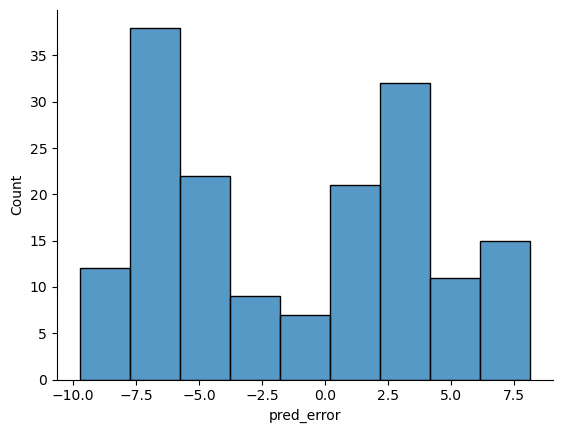

In [19]:
sns.histplot(data=RIF_predictions.query("binary==0 & compute_error==1"),
             x="pred_error"
            )
sns.despine()
plt.show()

This means that more isolates got UNDERPREDICTED than OVERPREDICTED

So for isolates predicted outside of their bin and in the wrong R/S category, MIC tends to be underestimated

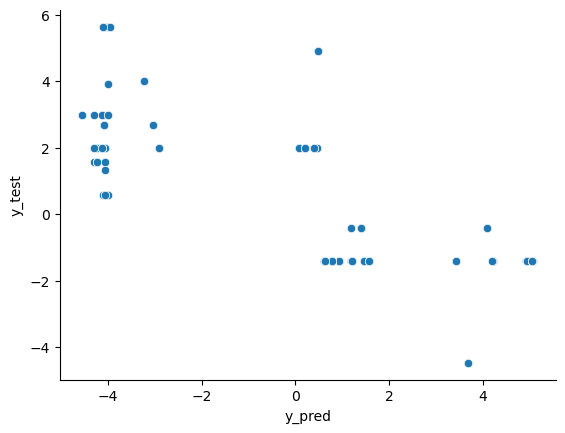

In [21]:
sns.scatterplot(data=RIF_predictions.query("binary==0 & compute_error==1"),
                x="y_pred",
                y="y_test"
               )
sns.despine()
plt.show()

(-1.9046707626182984, -1.71078954)

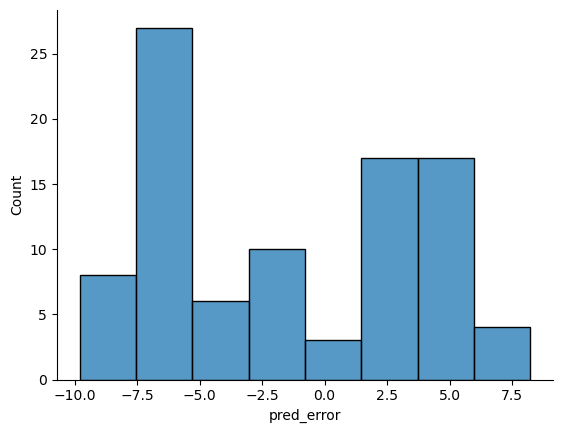

In [78]:
sns.histplot(RIF_predictions.query("binary==0")["pred_error"])


# WHO Model Analyses

,mutation,coef,pval,neutral_pval,BH_pval,Bonferroni_pval,BH_neutral_pval,Bonferroni_neutral_pval,Odds_Ratio,confidence
0,rpoB_p.Ser450Leu,2.295949,0.0,1.0,0.0,0.0,1.0,1.0,9.933858,1) Assoc w R
1,rpoB_p.Asp435Val,1.026295,0.0,1.0,0.0,0.0,1.0,1.0,2.790706,1) Assoc w R
2,rpoB_p.His445Tyr,0.763649,0.0,1.0,0.0,0.0,1.0,1.0,2.146093,1) Assoc w R
3,rpoB_p.His445Asp,0.746372,0.0,1.0,0.0,0.0,1.0,1.0,2.109334,1) Assoc w R
4,rpoB_p.Ser450Trp,0.421763,0.0,1.0,0.0,0.0,1.0,1.0,1.524647,1) Assoc w R
...,...,...,...,...,...,...,...,...,...,...
6121,mtrB_p.Met260Val,-0.105682,0.0,1.0,0.0,0.0,1.0,1.0,0.899711,NaN
6122,PC13,-0.108451,0.0,1.0,0.0,0.0,1.0,1.0,0.897223,NaN
6123,PC24,-0.114681,0.0,1.0,0.0,0.0,1.0,1.0,0.891650,NaN
6124,PC44,-0.114887,0.0,1.0,0.0,0.0,1.0,1.0,0.891467,NaN


In [192]:
who_variants_combined = pd.read_csv("/home/sak0914/who-analysis/analysis/who_confidence_2021.csv")

In [198]:
who_variants_combined.query("mutation in ['rpoB_p.Ser450Leu', 'rpoB_p.Ser450Trp']")

,drug,confidence,mutation
66,RIF,1) Assoc w R,rpoB_p.Ser450Leu
71,RIF,1) Assoc w R,rpoB_p.Ser450Trp


In [187]:
model_analysis

,mutation,coef,pval,neutral_pval,BH_pval,Bonferroni_pval,BH_neutral_pval,Bonferroni_neutral_pval,Odds_Ratio,confidence
0,rpoB_p.Ser450Leu,2.722690,0.000,1.000,0.000000,0.0,1.0,1.0,15.221206,1) Assoc w R
1,rpoB_p.Asp435Val,0.981234,0.000,1.000,0.000000,0.0,1.0,1.0,2.667747,1) Assoc w R
2,rpoB_p.His445Asp,0.746975,0.000,1.000,0.000000,0.0,1.0,1.0,2.110606,1) Assoc w R
3,rpoB_p.His445Tyr,0.735114,0.000,1.000,0.000000,0.0,1.0,1.0,2.085721,1) Assoc w R
4,rpoB_p.Ser450Trp,0.455561,0.000,1.000,0.000000,0.0,1.0,1.0,1.577058,1) Assoc w R
...,...,...,...,...,...,...,...,...,...,...
1326,PC45,-0.109826,0.000,1.000,0.000000,0.0,1.0,1.0,0.895990,NaN
1327,rpoB_c.2628T>G,-0.110730,0.002,0.994,0.012616,1.0,1.0,1.0,0.895181,NaN
1328,PC37,-0.129929,0.000,1.000,0.000000,0.0,1.0,1.0,0.878158,NaN
1329,PC44,-0.130100,0.000,1.000,0.000000,0.0,1.0,1.0,0.878007,NaN


In [148]:
st.spearmanr(df_syn_nonsyn_counts.query("Isolate not in @syn_mutations_only_isolates & Type == 'nonsyn'")["Prop"],
             df_syn_nonsyn_counts.query("Isolate not in @syn_mutations_only_isolates & Type == 'nonsyn'")["pred_MIC"]
            )

# Isolate not in @syn_mutations_only_isolates & 

SignificanceResult(statistic=0.532088670635878, pvalue=4.885048205995283e-99)

In [150]:
df_syn_nonsyn_counts.query("Type == 'nonsyn'")

,Isolate,Type,Count,pred_MIC,actual_MIC,MIC_diff,within_doubling,Total,Prop
0,00R0435,nonsyn,1,16.397648,1.000,15.397648,1,1,1.000000
1,01R0451,nonsyn,3,14.559205,1.000,13.559205,1,3,1.000000
2,01R1339,nonsyn,2,29.099692,1.000,28.099692,1,2,1.000000
4,0209397,nonsyn,1,0.057340,0.500,-0.442660,1,3,0.333333
7,0210028,nonsyn,2,0.040065,0.500,-0.459935,1,5,0.400000
...,...,...,...,...,...,...,...,...,...
2800,TDR58S102L002,nonsyn,3,42.769013,3.000,39.769013,1,3,1.000000
2802,TDR5S121L002,nonsyn,2,0.050015,0.125,-0.074985,1,5,0.400000
2803,TDR67S103L002,nonsyn,3,42.970183,3.000,39.970183,1,3,1.000000
2804,TDR69S127L002,nonsyn,2,42.775891,3.000,39.775891,1,2,1.000000


<Axes: xlabel='Prop', ylabel='pred_MIC'>

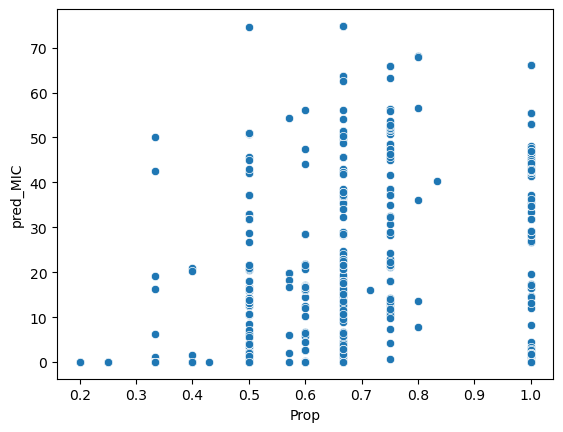

In [146]:
sns.scatterplot(data=df_syn_nonsyn_counts.query("Type == 'nonsyn'"),
                x="Prop",
                y="pred_MIC"
               )

In [152]:
# df_syn_nonsyn_counts.assign(Syn_Prop=df_syn_nonsyn_counts.groupby('Isolate')['Type'].apply(lambda group: group / group.sum()))

In [206]:
# Get all category 1 variants (don't use category 2 because it's the interim category
drug = "RIF"
import Bio
import Bio.SeqUtils
who_high_conf = who_variants.loc[(who_variants["drug"] == drug) & (who_variants.confidence.str.contains("|".join(["1"])))].reset_index(drop=True)

for _, row in who_high_conf.iterrows():
    if "," in row["genome_index"]:
        expanded_pos = row["genome_index"].split(",")
        
        for pos in expanded_pos:
            add_df = pd.DataFrame({"drug": drug, "genome_index": pos, "confidence": row["confidence"], "gene": row["gene"], "variant": row["variant"]}, index=[len(who_high_conf)])
            who_high_conf = pd.concat([who_high_conf, add_df])
          
who_high_conf = who_high_conf.loc[~who_high_conf.genome_index.str.contains(",")]
who_high_conf = who_high_conf.drop_duplicates().reset_index(drop=True)
who_high_conf["genome_index"] = who_high_conf["genome_index"].astype(int)

# convert them to 3-letter amino acid codes, which is what the ANN field has
for i, row in who_high_conf.iterrows():
    
    if len(row["variant"].split("_")) == 2:
        var = row["variant"].split("_")[1]
        expand_code = Bio.SeqUtils.IUPACData.protein_letters_1to3[var[0]] + var[1:-1] + Bio.SeqUtils.IUPACData.protein_letters_1to3[var[-1]]
        who_high_conf.loc[i, "ANN"] = expand_code
    else:
        who_high_conf.loc[i, "ANN"] = row["variant"]

In [36]:
S450T_isolates_only = combined_df.query("variant=='rpoB_p.Ser450Trp'").Isolate.values
print(S450T_isolates_only)

['ERR4796802' 'ERR4797415' 'ERR4813211' 'ERR3287769' 'ERR3287778'
 'ERR3287688' 'ERR4829382' 'ERR4829391' 'ERR4831525' 'ERR4829095'
 'ERR4831433' 'ERR2510291' 'ERR4813802' '00R0435' '1853' 'NLA009901354'
 'Peru3340' 'Peru4923']


In [45]:
combined_df.query("variant=='rpoB_p.Ser450Trp'").shape

(18, 16)

In [43]:
combined_df.query("Isolate in @S450T_isolates_only")[combined_df.groupby('Isolate')['Isolate'].transform('size') == 1]

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
2327,ERR4829382,8.0,8.0,50000.0,16.397648,1,8.397648,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
2949,ERR2510291,4.0,4.0,50000.0,16.397648,1,12.397648,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
3621,00R0435,1.0,1.0,50000.0,16.397648,1,15.397648,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
3729,1853,5.0,5.0,50000.0,16.397648,1,11.397648,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
3805,NLA009901354,5.0,5.0,50000.0,16.397648,1,11.397648,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R


In [151]:
# have S450 mutations, but predicted RIF-susceptible
combined_df.query("Isolate in ['ERR4796802', 'ERR4812953', 'ERR4813211']")

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
1070,ERR4796802,0.06,0.090,0.12,8.391592,0,8.301592,763031.0,T,C,rpoB,c.3225T>C,p.Ala1075Ala,rpoB_c.3225T>C,syn,5) Not assoc w R
1071,ERR4796802,0.06,0.090,0.12,8.391592,0,8.301592,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
1636,ERR4812953,0.03,0.045,0.06,9.580500,0,9.535500,764995.0,C,G,rpoC,c.1626C>G,p.Ala542Ala,rpoC_c.1626C>G,syn,5) Not assoc w R
1637,ERR4812953,0.03,0.045,0.06,9.580500,0,9.535500,761155.0,C,T,rpoB,c.1349C>T,p.Ser450Leu,rpoB_p.Ser450Leu,nonsyn,1) Assoc w R
1638,ERR4812953,0.03,0.045,0.06,9.580500,0,9.535500,766487.0,C,G,rpoC,c.3118C>G,p.Pro1040Ala,rpoC_p.Pro1040Ala,nonsyn,3) Uncertain significance
1655,ERR4813211,0.03,0.045,0.06,16.496858,0,16.451858,761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
1656,ERR4813211,0.03,0.045,0.06,16.496858,0,16.451858,762303.0,G,A,rpoB,c.2497G>A,p.Val833Met,rpoB_p.Val833Met,nonsyn,3) Uncertain significance


In [179]:
who_variants.query("drug=='RIF' & confidenec")

,drug,genome_index,confidence,gene,variant
1506,RIF,3878875,3) Uncertain significance,rpoA,rpoA_c-368t
1507,RIF,3067180,3) Uncertain significance,Rv2752c,Rv2752c_c-989a
1508,RIF,3878889,3) Uncertain significance,rpoA,rpoA_-382_ins_3_t_tgac
1509,RIF,3878698,3) Uncertain significance,rpoA,rpoA_a-191c
1510,RIF,3878709,3) Uncertain significance,rpoA,rpoA_a-202g
...,...,...,...,...,...
15907,RIF,3065374,5) Not assoc w R,Rv2752c,Rv2752c_A273V
15908,RIF,3065305,5) Not assoc w R,Rv2752c,Rv2752c_A296V
15909,RIF,3065824,5) Not assoc w R,Rv2752c,Rv2752c_P123L
15910,RIF,766085,5) Not assoc w R,rpoC,rpoC_P906A


In [81]:
pos = 761155
get_scores_by_nuc(pos)

Reference allele: C
Scores:            Max  Max_Sig  Min  Min_Sig
1596  7.961939      1.0  0.0      0.0
{'A': 0.46597078, 'C': 7.6729937, 'T': 2.4092815, 'G': 1.2482817, '-': 0.0}


In [82]:
pos = 763031
get_scores_by_nuc(pos)

Reference allele: T
Scores:       Max  Max_Sig       Min  Min_Sig
3493  0.0      0.0 -0.640886      1.0
{'A': 0.0, 'C': -0.29554462, 'T': -0.3918244, 'G': 0.0, '-': 0.0}


In [84]:
pos = 764995
get_scores_by_nuc(pos)

Reference allele: C
Scores:            Max  Max_Sig      Min  Min_Sig
5461  0.130165      1.0 -0.07951      0.0
{'A': 0.0, 'C': 0.05214694, 'T': 0.0, 'G': 0.078078516, '-': 0.0}


In [85]:
pos = 766487
get_scores_by_nuc(pos)

Reference allele: C
Scores:            Max  Max_Sig       Min  Min_Sig
6956  0.001324      0.0 -0.035132      0.0
{'A': 0.011255291, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [89]:
pos = 762303
get_scores_by_nuc(pos)

Reference allele: G
Scores:       Max  Max_Sig  Min  Min_Sig
2750  0.0      0.0  0.0      0.0
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


'T'

In [171]:
RIF_scores = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz").todense()

# num_samples x 5 nucleotides x longest_locus x num_loci
# print(RIF_scores.shape)

RIF_rpoBC_saliency = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")
RIF_rpoBC_saliency["POS"] = [int(float(val)) if val.replace(".", "").isnumeric() else val for val in RIF_rpoBC_saliency["Pos"].values]
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

def get_scores_by_nuc(pos):
    
    search_idx = RIF_rpoBC_saliency.query("POS==@pos").index.values[0]
    ref_allele = rpoBC_seqdf.iloc[:, search_idx].loc["MT_H37Rv"]
    print(f"Reference allele: {ref_allele}")

    if RIF_rpoBC_saliency.query("POS==@pos").Min.values[0] != 0:
        
        print(RIF_rpoBC_saliency.query("POS==@pos")[["Min", "Min_Sig"]])
        return pd.DataFrame(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, search_idx, :], axis=0).flatten())), index=[0]).T
    elif RIF_rpoBC_saliency.query("POS==@pos").Max.values[0] != 0:
        
        print(RIF_rpoBC_saliency.query("POS==@pos")[["Max", "Max_Sig"]])
        return pd.DataFrame(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, search_idx, :], axis=0).flatten())), index=[0]).T
    else:
        return None

In [172]:
pos = 761155
get_scores_by_nuc(pos)

Reference allele: C
           Max  Max_Sig
1596  7.961939      1.0


,0
A,0.465971
C,7.672994
T,2.409281
G,1.248282
-,0.000000


In [33]:
# for each sample, get the distribution of classified (MTBC) vs. unclassified (not MTBC) reads
unclassified_thresh = 25
high_unclassified_prop = []
finished_samples = 0

for sample_id in ['ERR4796802', 'ERR4812953', 'ERR4813211']:
    
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/{sample_id}/kraken/{sample_id}.krkn"):

        # kraken_class = pd.read_csv(os.path.join(validation_vcf_dir, sample_id, "kraken/kraken_classifications"), sep="\t", header=None)
        kraken_report = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/{sample_id}/kraken/{sample_id}.krkn", sep="\t", header=None)
        
        unclassified = len(kraken_report.loc[kraken_report[0] == "U"])
        unclassified_percent = unclassified / len(kraken_report)
        print(unclassified_percent)
            
        if unclassified_percent > unclassified_thresh:
            high_unclassified_prop.append([sample_id, unclassified_percent])
            
        finished_samples += 1
        
    else:
        raise ValueError(f"There is no kraken report file for {sample_id}")

0.0005476360294173162
0.02510999085603765
6.637954496218478e-06


In [18]:
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")


In [20]:
df_rif_val.FASTQ1_FILE.values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/20542/20542_R1.fastq.gz'

In [16]:
df_cryptic_og.query("ROLLINGDB_ID in ['ERR4796802', 'ERR4812953', 'ERR4813211']")[["ROLLINGDB_ID", "RIF_quality", "RIF"]]

,ROLLINGDB_ID,RIF_quality,RIF
2926,ERR4796802,HIGH,0.12
4631,ERR4812953,HIGH,0.06
4696,ERR4813211,HIGH,0.06


In [13]:
df_cryptic_og = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/cryptic_data_curated_filtered.csv")

In [156]:
get_scores_by_nuc(761277)

Reference allele: A
Scores:            Max  Max_Sig  Min  Min_Sig
1718  4.459873      1.0  0.0      0.0
{'A': 1.9019108, 'C': 0.58448714, 'T': 2.5579624, 'G': 0.06726146, '-': 0.0}


In [153]:
# only one isolate has an Assoc w R mutation and a predicted MIC < 0.5
# rpoB_p.Ile491Phe
# saliency score above indicates very high saliency score for A>T, but predicted low
combined_df.query("Initial_Confidence_Grading=='1) Assoc w R' & pred_MIC < 0.5")

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
1055,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,761277.0,A,T,rpoB,c.1471A>T,p.Ile491Phe,rpoB_p.Ile491Phe,nonsyn,1) Assoc w R


In [173]:
get_scores_by_nuc(762434)

Reference allele: T
           Min  Min_Sig
2890 -0.067079      0.0


,0
A,0.000000
C,0.000000
T,-0.024427
G,-0.042652
-,0.000000


In [174]:
get_scores_by_nuc(763031)

Reference allele: T
           Min  Min_Sig
3493 -0.640886      1.0


,0
A,0.000000
C,-0.295545
T,-0.391824
G,0.000000
-,0.000000


In [175]:
get_scores_by_nuc(759746)

Reference allele: C
         Min  Min_Sig
157 -0.09885      1.0


,0
A,0.000000
C,-0.046475
T,-0.052375
G,0.000000
-,0.000000


In [176]:
get_scores_by_nuc(761278)

Reference allele: T
           Max  Max_Sig
1719  0.224623      1.0


,0
A,0.000000
C,0.029813
T,0.216972
G,0.007651
-,0.000000


In [154]:
combined_df.query("Isolate=='ERR4796676'")

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
1052,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,762434.0,T,G,rpoB,c.2628T>G,p.Gly876Gly,rpoB_c.2628T>G,syn,5) Not assoc w R
1053,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,763031.0,T,C,rpoB,c.3225T>C,p.Ala1075Ala,rpoB_c.3225T>C,syn,5) Not assoc w R
1054,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,759746.0,C,T,mazF2,c.-4753G>A,.,mazF2_.,nonsyn,NaN
1055,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,761277.0,A,T,rpoB,c.1471A>T,p.Ile491Phe,rpoB_p.Ile491Phe,nonsyn,1) Assoc w R
1056,ERR4796676,4.0,4.0,50000.0,0.232351,0,-3.767649,761278.0,T,A,rpoB,c.1472T>A,p.Ile491Asn,rpoB_p.Ile491Asn,nonsyn,NaN


In [324]:
# Val833Met never occurs by itself. it's uncertain significance
combined_df.query("variant=='rpoB_p.Val833Met' & variants=='762303'")

# it only occurs once in the testing dataset
combined_df.query("variant=='rpoB_p.Val833Met'")

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,variants,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
1656,ERR4813211,0.03,0.045,0.06,16.496858,0,16.451858,"761155,762303",762303.0,G,A,rpoB,c.2497G>A,p.Val833Met,rpoB_p.Val833Met,nonsyn,3) Uncertain significance


In [325]:
combined_df.query("variants.str.contains('762303')")

,Isolate,lower,actual_MIC,upper,pred_MIC,within_doubling,MIC_diff,variants,POS,REF,ALT,GENE,NUC,PROT,variant,Type,Initial_Confidence_Grading
1655,ERR4813211,0.03,0.045,0.06,16.496858,0,16.451858,"761155,762303",761155.0,C,G,rpoB,c.1349C>G,p.Ser450Trp,rpoB_p.Ser450Trp,nonsyn,1) Assoc w R
1656,ERR4813211,0.03,0.045,0.06,16.496858,0,16.451858,"761155,762303",762303.0,G,A,rpoB,c.2497G>A,p.Val833Met,rpoB_p.Val833Met,nonsyn,3) Uncertain significance


In [314]:
nonsyn_model_analysis = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=WHO/dropAF_noSyn_unpooled/model_analysis.csv")
print(len(nonsyn_model_analysis.query("mutation=='rpoB_p.Val833Met'")))

nonsyn_model_matrix = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1+2/phenos=WHO/dropAF_noSyn_unpooled/model_matrix.pkl")
print('rpoB_p.Val833Met' in nonsyn_model_matrix.columns)

0
False


In [ ]:
SEARCH = 763031
alt_alleles = []

for i, isolate in enumerate(RIF_mispredict["Isolate"].values):

    pos_variants = []
    vcf_reader = vcf.Reader(filename=f"/n/scratch3/users/s/sak0914/annotated_VCF/{isolate}.eff.vcf")

    for record in vcf_reader:
        if record.POS == SEARCH:
            alt_alleles.append(record.ALT[0])

Int64Index([763031], dtype='int64', name='Pos')

In [ ]:
mispred_matrix.columns[mispred_matrix.sum(axis=0) == np.max(mispred_matrix.sum(axis=0))]

In [ ]:
df.query("MIC_diff < 0").columns[df.query("MIC_diff < 0").sum(axis=0) == np.max(df.query("MIC_diff < 0")[df.columns[df.dtypes == int]].sum(axis=0))]

In [ ]:
RIF_mispredict.query("MIC_diff > 0 & variants.str.contains('761155')")